<a href="https://colab.research.google.com/github/zakihir0/Google-Tunix-Hack---Train-a-model-to-show-its-work/blob/experiment/grpo_Gemma3_1B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("Installing required packages...")
%pip install -q dotenv
%pip install -q kagglehub
%pip install -q ipywidgets
%pip install -q tensorflow
%pip install -q tensorflow_datasets
%pip install -q tensorboardX
%pip install -q transformers
%pip install -q grain
%pip install -q git+https://github.com/jax-ml/jax
%pip install git+https://github.com/google/tunix
%pip install git+https://github.com/google/qwix
%pip uninstall -q flax -y
%pip install git+https://github.com/google/flax
!pip install flax
%pip install -q huggingface_hub
%pip install -q datasets
%pip install -q 'numpy>2'

Installing required packages...
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/google/tunix to /tmp/pip-req-build-lakzk3zi
  Running command git clone --filter=blob:none --quiet https://github.com/google/tunix /tmp/pip-req-build-lakzk3zi
  Resolved https://github.com/google/tunix to commit a8a69942d5020702ec064f761fbc496053152ddd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/google/qwix to /tmp/pip-req-build-fq79yil5
  Running command git clone --filter=blob:none --quiet https://github.com/google/qwix /tmp/pip-req-build-fq79yil5
  Resolved https://github.com/google/qwix to commit 98a44ed05b66773724c7daf0f2eb40c9916f6421
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  

feat(grpo): GRPO学習パイプライン全体の要件整理と機能追加

[環境・実行基盤]
- Kaggle / Colab / Local を自動判定する実行環境分岐を実装
- 環境ごとに作業ディレクトリ・ログ保存先・出力先を切り替え
- ColabではGoogle Driveを自動マウントし結果を永続化
- Kaggleでは /kaggle/working 配下に全成果物を保存

[データセット]
- GSM8K（Kaggle CSV）を kagglehub 経由で自動取得
- train / test をCSVから読み込み grain.Dataset に変換
- 質問文・正解数値（####以降）を分離して保持
- TRAIN_FRACTION に基づく train / val 分割を実装

[プロンプト・前処理]
- reasoning / answer タグを強制するシステムプロンプトを使用
- テンプレート形式で user / model ターンを明示
- 数値抽出・フォーマット検証用の正規表現を定義

[モデル]
- gemma-3-1b-it を Hugging Face から取得
- safetensors から JAX/Flax モデルを構築
- LoRA (rank=64, alpha=64) を指定レイヤに適用
- TP/FSDP メッシュ構成を TPU 数に応じて切替

[生成・推論]
- tunix Sampler による autoregressive 生成を使用
- temperature / top-k / top-p を設定可能
- greedy / standard / liberal の生成設定を定義
- verbose モードで生成テキストを標準出力に表示

[学習（GRPO）]
- GRPO (Generalized Reparameterized Policy Optimization) を使用
- num_generations / num_iterations / beta / epsilon を明示設定
- optax AdamW + warmup cosine decay を使用
- gradient clipping を有効化
- チェックポイントを一定stepごとに保存

[報酬関数]
- 正解数値一致を評価する check_answer
- 数値抽出の正当性を評価する check_numbers
- フォーマット厳密一致 / 近似一致報酬
- ステップ論理性・自己修正表現の報酬
- failure-like 出力（unknown/assume/repeat/欠落）へのペナルティ
- 報酬関数セットを辞書で切替可能に設計

[Failure統計・品質分析]
- unknown / assume / repetition / answer欠落 などをヒューリスティック検出
- 問題単位で failure-like 発生率を集計
- 学習後評価時に failure_rate と内訳を算出

[評価]
- 正解率 / 部分正解率 / フォーマット正解率を算出
- num_passes による複数生成の集約評価を実装
- verbose 時は Question / Answer / Response を出力
- baseline（学習なし）と学習後モデルを比較評価

[ロギング（Policy B）]
- TensorBoard に eval 指標を追加で書き込み
  - accuracy / partial_accuracy / format_accuracy
  - failure_rate と各種 failure 内訳
- tunix 標準ログと同一 log_dir に統合
- run ごとに SummaryWriter を管理

[成果物保存]
- tensorboard logs / checkpoints を実行単位で保存
- Google Drive または working ディレクトリにコピー
- 使用した報酬関数セットを JSON として保存

[実験比較・可視化]
- TensorBoard event ファイルを直接読み込み
- 全runを統合した long-format CSV を生成
- tag × run を1枚のPNGにまとめて可視化
- PNG下部に各runで使用した報酬関数を注記
- 各指標ごとの wide-format CSV を出力

[再現性・実験管理]
- 実行時刻ベースの RUN_STAMP により成果物を分離
- baseline + 複数報酬セットを1スクリプトで一括実行
- 後処理（比較・可視化）まで含めた end-to-end 実験構成

[ENV] colab
Mounted at /content/drive
[Drive] mounted: True
[PATHS]
 BASE_LOG_DIR: /tmp/content/tmp/tensorboard/grpo
 CKPT_DIR    : /tmp/content/ckpts
 TRAIN_DATA_DIR: /content/data/train
 TEST_DATA_DIR : /content/data/test
 DST_ROOT    : /content/drive/MyDrive/grpo_runs/20260109_021435


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


Using Colab cache for faster access to the 'grade-school-math-8k-q-a' dataset.
Copied main_test.csv → /content/data/train/main_test.csv
Copied main_train.csv → /content/data/train/main_train.csv
Copied socratic_train.csv → /content/data/train/socratic_train.csv
Copied socratic_test.csv → /content/data/train/socratic_test.csv
Using Colab cache for faster access to the 'grade-school-math-8k-q-a' dataset.
Copied main_test.csv → /content/data/test/main_test.csv
Copied main_train.csv → /content/data/test/main_train.csv
Copied socratic_train.csv → /content/data/test/socratic_train.csv
Copied socratic_test.csv → /content/data/test/socratic_test.csv
dataset contains batches: (3364, 374, 64)
{'answer': array(['3'], dtype='<U1'),
 'prompts': array(['<start_of_turn>user\nYou are given a problem. First, think about the problem and provide your reasoning. Place it between <reasoning> and </reasoning>. Then, provide the final answer (i.e., just one numerical value) between <answer> and </answer>.\n\

Fetching 10 files:   0%|          | 0/10 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

...

  0%|          | 0/64 [00:00<?, ?it/s]

Question:	Mr Hezekiah had 20 trucks from his store supplying fertiliser to different farmers in his hometown dispatched for delivery on a particular day. Each truck was carrying 20 tons of fertiliser packed in bags. Two hours after the trucks had departed for delivery, Mr Hezekiah got the news that a quarter of the number of lorries dispatched for delivery had mechanical failures on the road and could not deliver the fertilisers to the farmers. Calculate the total number of tons of fertiliser that reached the farmers that day?
Correct Answer:	300
Response:	reasoning:
The problem states that each truck carried 20 tons of fertiliser. Mr. Hezekiah dispatched 20 trucks. Therefore, the total amount of fertiliser initially planned was 20 trucks * 20 tons/truck = 400 tons.
Two hours after the trucks departed, a quarter of the lorries failed. This means that the number of lorries that failed is (1/4) * 20 = 5 lorries.
Each lorry carried 20 tons of fertiliser. So, the total amount of fertiliser

Actor Training:   0%|          | 0/3364 [00:00<?, ?step/s]

  0%|          | 0/64 [00:00<?, ?it/s]

Question:	Mr Hezekiah had 20 trucks from his store supplying fertiliser to different farmers in his hometown dispatched for delivery on a particular day. Each truck was carrying 20 tons of fertiliser packed in bags. Two hours after the trucks had departed for delivery, Mr Hezekiah got the news that a quarter of the number of lorries dispatched for delivery had mechanical failures on the road and could not deliver the fertilisers to the farmers. Calculate the total number of tons of fertiliser that reached the farmers that day?
Correct Answer:	300
Response:	 Reasoning:
First, we need to find out how many lorries were dispatched. We are given that 20 trucks were dispatched. Then, we are told that a quarter of the lorries failed. That means the number of lorries that failed is $\frac{1}{4} \times 20 = 5$ lorries.
Each lorry carried 20 tons of fertiliser. So, the total amount of fertiliser that failed is $5 \times 20 = 100$ tons.
The number of lorries that successfully delivered the fertil

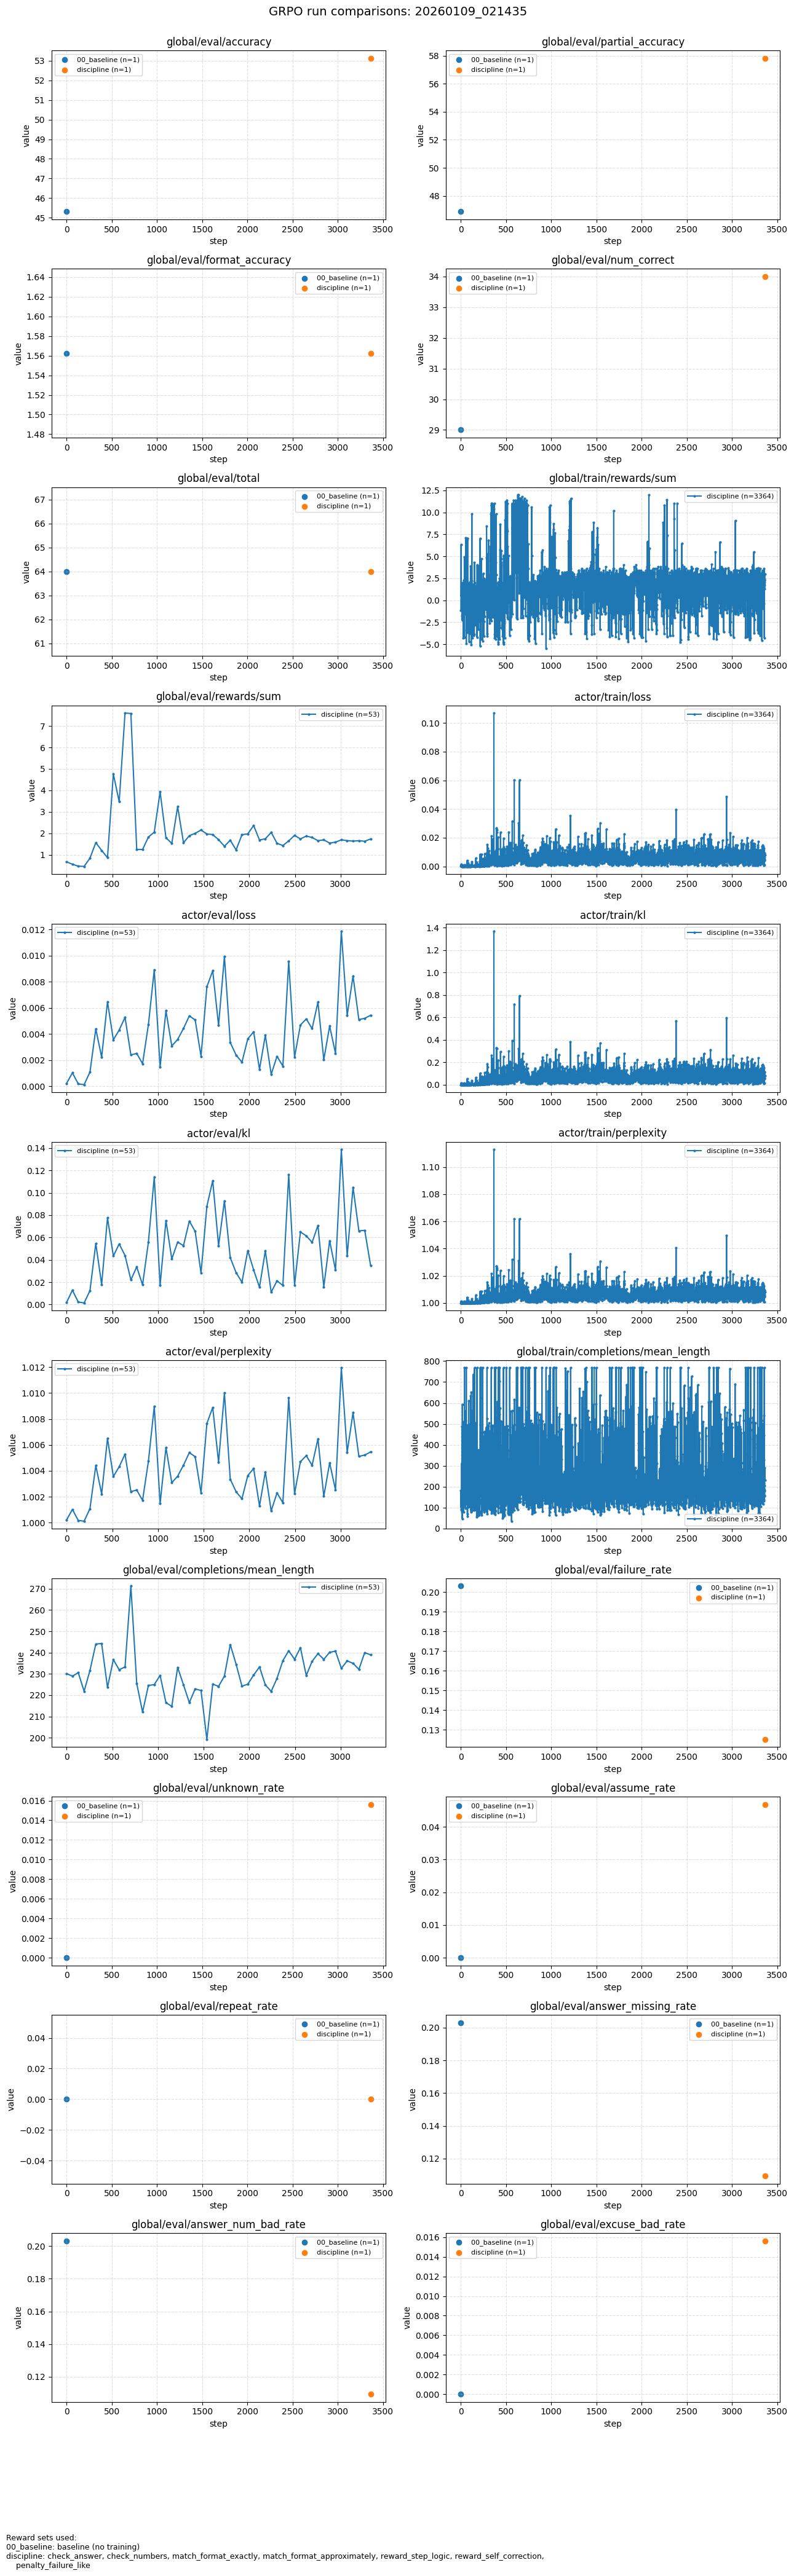

[OK] saved PNG: /content/drive/MyDrive/grpo_runs/20260109_021435/analysis_outputs/compare_plots_all_tags.png
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_021435/analysis_outputs/global__eval__accuracy_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_021435/analysis_outputs/global__eval__partial_accuracy_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_021435/analysis_outputs/global__eval__format_accuracy_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_021435/analysis_outputs/global__eval__num_correct_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_021435/analysis_outputs/global__eval__total_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_021435/analysis_outputs/global__train__rewards__sum_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_021435/analysis_outputs/global__eval__rewards__sum_wide.csv
[OK] wide: /content/drive/MyDrive/grpo_runs/20260109_021435/analysis_outputs/actor__train__loss_wide.csv

In [2]:
# ============================================================
# GRPO (tunix) + Custom rewards + Policy B (log ACC + FailureStats into TensorBoard)
# + Verbose generation printing (optional)
# + "failure-like" rate statistics (unknown/assume/repeat/answer-format issues)
# + Copy logs -> (Colab: Google Drive) / (Kaggle: /kaggle/working)
# + Compare runs from the saved root (merged CSV + wide CSVs + ONE PNG)
#   - PNG also shows reward-function sets used per run (figure footer)
#
# Notes:
# - Writes extra scalars into SAME log_dir as tunix:
#   global/eval/accuracy, global/eval/partial_accuracy, global/eval/format_accuracy,
#   global/eval/num_correct, global/eval/total
#   + global/eval/failure_rate and breakdown rates
# ============================================================

# ============================================================
# 0) Environment switch (Kaggle vs Colab) + Paths + (optional) Drive mount
# ============================================================
import os, sys, time
from pathlib import Path

def detect_env() -> str:
  if os.environ.get("KAGGLE_KERNEL_RUN_TYPE") or os.path.exists("/kaggle/working"):
    return "kaggle"
  try:
    import google.colab  # noqa
    return "colab"
  except Exception:
    return "local"

ENV = detect_env()
print("[ENV]", ENV)

RUN_STAMP = time.strftime("%Y%m%d_%H%M%S")

if ENV == "kaggle":
  WORK_DIR = Path("/kaggle/working")
  TMP_DIR  = WORK_DIR / "tmp"
  OUT_ROOT = WORK_DIR / "grpo_runs" / RUN_STAMP

  BASE_LOG_DIR = str(TMP_DIR / "tensorboard" / "grpo")
  CKPT_DIR     = str(TMP_DIR / "ckpts")
  TRAIN_DATA_DIR = str(WORK_DIR / "data" / "train")
  TEST_DATA_DIR  = str(WORK_DIR / "data" / "test")

  ENABLE_DRIVE_COPY = False
  DST_ROOT = str(OUT_ROOT)

elif ENV == "colab":
  WORK_DIR = Path("/content")
  TMP_DIR  = Path("/tmp/content")
  TRAIN_DATA_DIR = str(WORK_DIR / "data" / "train")
  TEST_DATA_DIR  = str(WORK_DIR / "data" / "test")

  BASE_LOG_DIR = str(TMP_DIR / "tmp" / "tensorboard" / "grpo")
  CKPT_DIR     = str(TMP_DIR / "ckpts")

  # (Colab) Mount Google Drive (once)
  ENABLE_DRIVE_COPY = True
  try:
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
      drive.mount("/content/drive")
    print("[Drive] mounted:", Path("/content/drive/MyDrive").exists())
  except Exception as e:
    print("[Drive] mount skipped:", e)
    ENABLE_DRIVE_COPY = False

  if ENABLE_DRIVE_COPY:
    DST_ROOT = str(Path("/content/drive/MyDrive/grpo_runs") / RUN_STAMP)
  else:
    DST_ROOT = str((WORK_DIR / "grpo_runs" / RUN_STAMP))

else:
  WORK_DIR = Path(".").resolve()
  TMP_DIR  = WORK_DIR / "tmp"
  BASE_LOG_DIR = str(TMP_DIR / "tensorboard" / "grpo")
  CKPT_DIR     = str(TMP_DIR / "ckpts")
  TRAIN_DATA_DIR = str(WORK_DIR / "data" / "train")
  TEST_DATA_DIR  = str(WORK_DIR / "data" / "test")
  ENABLE_DRIVE_COPY = False
  DST_ROOT = str((WORK_DIR / "grpo_runs" / RUN_STAMP))

Path(BASE_LOG_DIR).mkdir(parents=True, exist_ok=True)
Path(CKPT_DIR).mkdir(parents=True, exist_ok=True)
Path(TRAIN_DATA_DIR).mkdir(parents=True, exist_ok=True)
Path(TEST_DATA_DIR).mkdir(parents=True, exist_ok=True)
Path(DST_ROOT).mkdir(parents=True, exist_ok=True)

print("[PATHS]")
print(" BASE_LOG_DIR:", BASE_LOG_DIR)
print(" CKPT_DIR    :", CKPT_DIR)
print(" TRAIN_DATA_DIR:", TRAIN_DATA_DIR)
print(" TEST_DATA_DIR :", TEST_DATA_DIR)
print(" DST_ROOT    :", DST_ROOT)

# ============================================================
# 1) Imports
# ============================================================
import csv, json, shutil, glob, math, re, textwrap
from pprint import pprint

from flax import nnx
import grain
import jax
import optax
import qwix
from tqdm.auto import tqdm
from huggingface_hub import snapshot_download
from orbax import checkpoint as ocp

from tunix.generate import sampler as sampler_lib
from tunix.generate import tokenizer_adapter as tokenizer_lib
from tunix.models.gemma3 import model as gemma_lib
from tunix.models.gemma3 import params_safetensors as params_safetensors_lib
from tunix.rl import rl_cluster as rl_cluster_lib
from tunix.rl.grpo.grpo_learner import GRPOConfig, GRPOLearner
from tunix.rl.rollout import base_rollout
from tunix.sft import metrics_logger

from tensorboardX import SummaryWriter
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 2) Configs
# ============================================================
MODEL_ID = "google/gemma-3-1b-it"
GEMMA_TOKENIZER_PATH = "gs://gemma-data/tokenizers/tokenizer_gemma3.model"

TRAIN_FRACTION = 0.9

# LoRA
RANK  = 64
ALPHA = 64.0

# Mesh
NUM_TPUS = len(jax.devices())
if NUM_TPUS == 8:
  MESH_COUNTS = (1, 4)
elif NUM_TPUS == 1:
  MESH_COUNTS = (1, 1)
else:
  raise ValueError(f"Unsupported number of TPUs: {NUM_TPUS}")

MESH = [
    MESH_COUNTS,
    ("fsdp", "tp"),
]

# GRPO generation
MAX_PROMPT_LENGTH       = 256
TOTAL_GENERATION_STEPS  = 768
TEMPERATURE             = 0.9
TOP_P                   = 1.0
TOP_K                   = 50
NUM_GENERATIONS         = 2
NUM_ITERATIONS          = 1
BETA                    = 0.08
EPSILON                 = 0.2

# Training
TRAIN_MICRO_BATCH_SIZE  = 1
NUM_BATCHES             = 3738
NUM_TEST_BATCHES        = 64
EVAL_EVERY_N_STEPS      = 64
NUM_EPOCHS              = 1
MAX_STEPS = int(NUM_BATCHES * NUM_ITERATIONS * TRAIN_FRACTION * NUM_EPOCHS)

LEARNING_RATE = 3e-6
B1 = 0.9
B2 = 0.99
WEIGHT_DECAY = 0.1
WARMUP_STEPS = 0.1 * MAX_STEPS
MAX_GRAD_NORM = 0.1

SAVE_INTERVAL_STEPS = 500
MAX_TO_KEEP   = 4

GENERATION_CONFIGS = {
    "greedy":   {"temperature": None, "top_k": 1,    "top_p": None},
    "standard": {"temperature": 0.7,  "top_k": 50,   "top_p": 0.95},
    "liberal":  {"temperature": 0.85, "top_k": 2000, "top_p": 1.0},
}

# Verbose printing controls (for evaluate())
VERBOSE_DEFAULT = True
PRINT_EVERY_N = 1
PRINT_MAX_PER_BATCH = None

# Failure-stat controls
FAIL_REPETITION_DUP_FRAC = 0.35
FAIL_REPETITION_MIN_SENT = 6

# Prompt format
reasoning_start = "<reasoning>"
reasoning_end   = "</reasoning>"
solution_start  = "<answer>"
solution_end    = "</answer>"

SYSTEM_PROMPT = f"""You are given a problem. First, think about the problem and provide your reasoning. Place it between {reasoning_start} and {reasoning_end}. Then, provide the final answer (i.e., just one numerical value) between {solution_start} and {solution_end}."""

TEMPLATE = """<start_of_turn>user
{system_prompt}

{question}<end_of_turn>
<start_of_turn>model
"""

# ============================================================
# 3) Dataset (Kaggle GSM8K csv via kagglehub)
# ============================================================
def extract_hash_answer(text: str) -> str | None:
  if "####" not in text:
    return None
  return text.split("####")[1].strip()

def download_kaggle_dataset(target_dir="./data/gsm8k"):
  os.makedirs(target_dir, exist_ok=True)
  import kagglehub
  # Kaggle環境ではlogin不要なことが多いが、設定済みなら通る
  if ENV == "kaggle":
    try:
      kagglehub.login()
    except Exception:
      pass
  src = kagglehub.dataset_download("thedevastator/grade-school-math-8k-q-a")
  src = Path(src)
  dst = Path(target_dir)
  for csv_file in src.glob("*.csv"):
    shutil.copy2(csv_file, dst / csv_file.name)
    print(f"Copied {csv_file.name} → {dst/csv_file.name}")
  return target_dir

def get_dataset(data_dir, split="train") -> grain.MapDataset:
  os.makedirs(data_dir, exist_ok=True)
  kaggle_dir = download_kaggle_dataset(data_dir)
  file_name = "main_" + split + ".csv"
  csv_path = os.path.join(kaggle_dir, file_name)

  data = []
  with open(csv_path, newline="", encoding="utf-8") as csvfile:
    reader = csv.DictReader(csvfile)
    for row in reader:
      data.append({"question": row["question"], "answer": row["answer"]})

  def _as_text(v):
    return v if isinstance(v, str) else v.decode("utf-8")

  dataset = (
      grain.MapDataset.source(data)
      .shuffle(seed=42)
      .map(
          lambda x: {
              "prompts": TEMPLATE.format(
                  system_prompt=SYSTEM_PROMPT,
                  question=_as_text(x["question"]),
              ),
              "question": _as_text(x["question"]),
              "answer": extract_hash_answer(_as_text(x["answer"])),
          }
      )
  )
  return dataset

dataset_all = get_dataset(TRAIN_DATA_DIR, "train").batch(TRAIN_MICRO_BATCH_SIZE)[:NUM_BATCHES]

if TRAIN_FRACTION == 1.0:
  train_dataset = dataset_all.repeat(NUM_EPOCHS)
  val_dataset = None
else:
  split_i = int(len(dataset_all) * TRAIN_FRACTION)
  train_dataset = dataset_all[:split_i].repeat(NUM_EPOCHS)
  val_dataset   = dataset_all[split_i:].repeat(NUM_EPOCHS)

test_dataset = get_dataset(TEST_DATA_DIR, "test").batch(TRAIN_MICRO_BATCH_SIZE)[:NUM_TEST_BATCHES]

print("dataset contains batches:", (len(train_dataset), len(val_dataset) if val_dataset is not None else 0, len(test_dataset)))
for ele in train_dataset[:1]:
  pprint(ele)

# ============================================================
# 4) Model load + LoRA + tokenizer
# ============================================================
ignore_patterns = ["*.pth"]
print(f"Downloading {MODEL_ID} from Hugging Face...")
local_model_path = snapshot_download(repo_id=MODEL_ID, ignore_patterns=ignore_patterns)
print(f"Model successfully downloaded to: {local_model_path}")

EOS_TOKENS = []
generation_config_path = os.path.join(local_model_path, "generation_config.json")
if os.path.exists(generation_config_path):
  with open(generation_config_path, "r") as f:
    generation_configs = json.load(f)
  EOS_TOKENS = generation_configs.get("eos_token_id", [])
  print(f"Using EOS token IDs (from config): {EOS_TOKENS}")

MODEL_CP_PATH = local_model_path
model_config = gemma_lib.ModelConfig.gemma3_1b_it()

mesh = jax.make_mesh(*MESH, axis_types=(jax.sharding.AxisType.Auto,) * len(MESH[0]))
with mesh:
  gemma3 = params_safetensors_lib.create_model_from_safe_tensors(
      MODEL_CP_PATH, (model_config), mesh
  )

import numpy as np
import jax

def mesh_is_effectively_single(mesh):
  # mesh.shape は {'fsdp': 1, 'tp': 1} のような dict を想定
  try:
    sizes = list(mesh.shape.values())
  except Exception:
    return True
  return int(np.prod(sizes)) == 1

def get_lora_model(base_model, mesh):
  lora_provider = qwix.LoraProvider(
      module_path=(
          ".*q_einsum|.*kv_einsum|.*gate_proj|.*down_proj|.*up_proj|"
          ".*attn_vec_einsum"
      ),
      rank=RANK,
      alpha=ALPHA,
  )
  model_input = base_model.get_model_input()

  # ★できればrngsも渡す（警告の根を潰す）
  lora_model = qwix.apply_lora_to_model(
      base_model, lora_provider,
      rngs=nnx.Rngs(0),
      **model_input
  )

  with mesh:
    state = nnx.state(lora_model)
    pspecs = nnx.get_partition_spec(state)

    if mesh_is_effectively_single(mesh):
      sharded_state = state  # skip constraint
    else:
      sharded_state = jax.lax.with_sharding_constraint(state, pspecs)

    nnx.update(lora_model, sharded_state)

  return lora_model

lora_policy = get_lora_model(gemma3, mesh=mesh)
tokenizer = tokenizer_lib.Tokenizer(tokenizer_path=GEMMA_TOKENIZER_PATH)

if tokenizer.eos_id() not in EOS_TOKENS:
  EOS_TOKENS.append(tokenizer.eos_id())
print(f"Using EOS token IDs (final): {EOS_TOKENS}")

# ============================================================
# 5) Regex/extractors (evaluate/rewards/failure)
# ============================================================
match_format = re.compile(
    rf"^[\s]{{0,}}"
    rf"{reasoning_start}.+?{reasoning_end}.*?"
    rf"{solution_start}(.+?){solution_end}"
    rf"[\s]{{0,}}$",
    flags=re.MULTILINE | re.DOTALL,
)
match_numbers = re.compile(
    rf"{solution_start}\s*([-+\d\.]+)", flags=re.MULTILINE | re.DOTALL
)

match_reasoning = re.compile(
    rf"{reasoning_start}(.+?){reasoning_end}",
    flags=re.MULTILINE | re.DOTALL,
)
match_answer_block = re.compile(
    rf"{solution_start}(.+?){solution_end}",
    flags=re.MULTILINE | re.DOTALL,
)

FAIL_PATTERNS_UNKNOWN = [
  "not given", "not provided", "cannot be determined", "unknown",
  "we are not given", "insufficient information", "missing information",
]
FAIL_PATTERNS_ASSUME = [
  "let's assume", "lets assume", "assume that", "suppose that", "we can assume",
  "let us assume",
]

def is_failure_like(prompt: str, completion: str) -> dict:
  """
  Heuristic detector for the failure you showed:
  - "unknown/not provided/assume" excuses
  - missing <answer> block
  - answer contains != 1 numeric
  - repetitive reasoning (high duplicate sentence fraction)
  - "unknown" excuse even though prompt has enough digits (>=2)
  """
  completion = completion or ""
  txt = completion.lower()

  fail_unknown = any(p in txt for p in FAIL_PATTERNS_UNKNOWN)
  fail_assume  = any(p in txt for p in FAIL_PATTERNS_ASSUME)

  m_ans = match_answer_block.search(completion)
  if m_ans is None:
    ans_nums = []
  else:
    ans_nums = re.findall(r"[-+]?\d*\.?\d+", m_ans.group(1))
  fail_answer_missing = (m_ans is None)
  fail_answer_num_bad = (len(ans_nums) != 1)

  rep_bad = False
  rm = match_reasoning.search(completion)
  if rm is not None:
    rtxt = re.sub(r"\s+", " ", rm.group(1).strip().lower())
    parts = [s.strip() for s in re.split(r"[.\n;]+", rtxt) if s.strip()]
    if len(parts) >= int(FAIL_REPETITION_MIN_SENT):
      dup_frac = 1.0 - (len(set(parts)) / max(1, len(parts)))
      rep_bad = (dup_frac >= float(FAIL_REPETITION_DUP_FRAC))

  nums_in_prompt = re.findall(r"\d+", str(prompt))
  excuse_bad = fail_unknown and (len(nums_in_prompt) >= 2)

  failure = (fail_unknown or fail_assume or rep_bad or fail_answer_missing or fail_answer_num_bad or excuse_bad)

  return {
    "failure": bool(failure),
    "fail_unknown": bool(fail_unknown),
    "fail_assume": bool(fail_assume),
    "fail_repeat": bool(rep_bad),
    "fail_answer_missing": bool(fail_answer_missing),
    "fail_answer_num_bad": bool(fail_answer_num_bad),
    "fail_excuse_bad": bool(excuse_bad),
  }

# ============================================================
# 6) Generation & evaluation
# ============================================================
def build_sampler(model=None):
  mdl = model if model is not None else lora_policy
  return sampler_lib.Sampler(
      transformer=mdl,
      tokenizer=tokenizer,
      cache_config=sampler_lib.CacheConfig(
          cache_size=MAX_PROMPT_LENGTH + TOTAL_GENERATION_STEPS + 256,
          num_layers=model_config.num_layers,
          num_kv_heads=model_config.num_kv_heads,
          head_dim=model_config.head_dim,
      ),
  )

def generate(question, sampler, temperature=0.7, top_k=50, top_p=0.95, seed=None):
  if isinstance(question, str):
    input_batch = [TEMPLATE.format(system_prompt=SYSTEM_PROMPT, question=question)]
  else:
    input_batch = [TEMPLATE.format(system_prompt=SYSTEM_PROMPT, question=q) for q in question]

  out_data = sampler(
      input_strings=input_batch,
      max_generation_steps=TOTAL_GENERATION_STEPS,
      temperature=temperature,
      top_k=top_k,
      top_p=top_p,
      echo=False,
      seed=seed if seed is not None else None,
      eos_tokens=EOS_TOKENS,
  )
  output = out_data.text
  return output[0] if isinstance(question, str) else output

def evaluate(
    dataset,
    sampler,
    temperature=0.7,
    top_k=50,
    top_p=0.95,
    num_passes=1,
    corr_lst=False,
    make_lst=False,
    verbose=None,
    print_every_n=1,
    print_max_per_batch=None,
):
  """
  Returns:
    metrics: (num_correct, total, acc%, partial%, format%)
    stats: dict with failure-like rates
  """
  if verbose is None:
    verbose = VERBOSE_DEFAULT

  response_lst = []
  corr = partially_corr = corr_format = total = 0

  fail_ctr = 0
  fail_unknown_ctr = 0
  fail_assume_ctr = 0
  fail_repeat_ctr = 0
  fail_ans_missing_ctr = 0
  fail_ans_num_bad_ctr = 0
  fail_excuse_bad_ctr = 0

  for batch_i, batch in enumerate(tqdm(dataset)):
    answers = batch["answer"]
    questions = batch["question"]

    multiple_call_responses = [[] for _ in range(len(questions))]
    for p in range(num_passes):
      responses = generate(questions, sampler, temperature, top_k, top_p, seed=p)

      for idx, response in enumerate(responses):
        multiple_call_responses[idx].append(response)

        if verbose:
          if (total + idx) % max(1, int(print_every_n)) == 0:
            if print_max_per_batch is None or idx < int(print_max_per_batch):
              print(f"Question:\t{questions[idx]}")
              print(f"Correct Answer:\t{answers[idx]}")
              print(f"Response:\t{response}")
              print("-" * 50)

    for question, multiple_call_response, answer in zip(questions, multiple_call_responses, answers):
      corr_ctr_per_question = partially_corr_per_question = corr_format_per_question = 0

      per_q_failure = False
      per_q_unknown = False
      per_q_assume = False
      per_q_repeat = False
      per_q_ans_missing = False
      per_q_ans_num_bad = False
      per_q_excuse_bad = False

      for response in multiple_call_response:
        extracted_response = (guess.group(1) if (guess := match_numbers.search(response)) is not None else "-1000000")

        try:
          if float(extracted_response.strip()) == float(answer.strip()):
            corr_ctr_per_question += 1
          ratio = float(extracted_response.strip()) / float(answer.strip())
          if 0.9 <= ratio <= 1.1:
            partially_corr_per_question += 1
        except:
          pass

        if match_format.search(response) is not None:
          corr_format_per_question += 1

        fd = is_failure_like(question, response)
        per_q_failure |= fd["failure"]
        per_q_unknown |= fd["fail_unknown"]
        per_q_assume  |= fd["fail_assume"]
        per_q_repeat  |= fd["fail_repeat"]
        per_q_ans_missing |= fd["fail_answer_missing"]
        per_q_ans_num_bad |= fd["fail_answer_num_bad"]
        per_q_excuse_bad  |= fd["fail_excuse_bad"]

        if corr_ctr_per_question > 0 and partially_corr_per_question > 0 and corr_format_per_question > 0 and (not per_q_failure):
          break

      if corr_ctr_per_question > 0:
        corr += 1
        if corr_lst and make_lst:
          response_lst.append((question, answer, multiple_call_response))
      else:
        if (not corr_lst) and make_lst:
          response_lst.append((question, answer, multiple_call_response))

      if partially_corr_per_question > 0:
        partially_corr += 1
      if corr_format_per_question > 0:
        corr_format += 1

      if per_q_failure: fail_ctr += 1
      if per_q_unknown: fail_unknown_ctr += 1
      if per_q_assume: fail_assume_ctr += 1
      if per_q_repeat: fail_repeat_ctr += 1
      if per_q_ans_missing: fail_ans_missing_ctr += 1
      if per_q_ans_num_bad: fail_ans_num_bad_ctr += 1
      if per_q_excuse_bad: fail_excuse_bad_ctr += 1

      total += 1

      if verbose and (total % 10 == 0):
        print(
          f"===> corr={corr}, total={total}, "
          f"acc%={corr / total * 100:.2f}, "
          f"partial%={partially_corr / total * 100:.2f}, "
          f"format%={corr_format / total * 100:.2f}, "
          f"failure_rate={fail_ctr / total * 100:.2f}%"
        )

  metrics = (corr, total, corr / total * 100, partially_corr / total * 100, corr_format / total * 100)
  stats = {
    "failure_rate": fail_ctr / max(1, total),
    "unknown_rate": fail_unknown_ctr / max(1, total),
    "assume_rate": fail_assume_ctr / max(1, total),
    "repeat_rate": fail_repeat_ctr / max(1, total),
    "answer_missing_rate": fail_ans_missing_ctr / max(1, total),
    "answer_num_bad_rate": fail_ans_num_bad_ctr / max(1, total),
    "excuse_bad_rate": fail_excuse_bad_ctr / max(1, total),
  }

  if make_lst:
    return metrics, stats, response_lst
  return metrics, stats

# ============================================================
# 7) Optimizer + GRPO config
# ============================================================
optimizer = optax.adamw(
    learning_rate=optax.schedules.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=LEARNING_RATE,
        warmup_steps=WARMUP_STEPS,
        decay_steps=MAX_STEPS,
        end_value=0.0,
    ),
    b1=B1,
    b2=B2,
    weight_decay=WEIGHT_DECAY,
)
if MAX_GRAD_NORM is not None:
  optimizer = optax.chain(optax.clip_by_global_norm(max_norm=MAX_GRAD_NORM), optimizer)

grpo_config = GRPOConfig(
    num_generations=NUM_GENERATIONS,
    num_iterations=NUM_ITERATIONS,
    beta=BETA,
    epsilon=EPSILON,
)

# ============================================================
# 8) Trainer/cluster builder (log_dir per run)
# ============================================================
def build_trainer_with_logdir(log_subdir, reward_fns):
  log_dir = os.path.join(BASE_LOG_DIR, log_subdir)
  os.makedirs(log_dir, exist_ok=True)

  ckpt_dir = os.path.join(CKPT_DIR, log_subdir)
  os.makedirs(ckpt_dir, exist_ok=True)

  checkpointing_options = ocp.CheckpointManagerOptions(
      save_interval_steps=SAVE_INTERVAL_STEPS, max_to_keep=MAX_TO_KEEP
  )
  metrics_logging_options = metrics_logger.MetricsLoggerOptions(
      log_dir=log_dir, flush_every_n_steps=20
  )
  cluster_config = rl_cluster_lib.ClusterConfig(
      role_to_mesh={
          rl_cluster_lib.Role.ACTOR: mesh,
          rl_cluster_lib.Role.REFERENCE: mesh,
          rl_cluster_lib.Role.ROLLOUT: mesh,
      },
      rollout_engine="vanilla",
      offload_to_cpu=False,
      training_config=rl_cluster_lib.RLTrainingConfig(
          actor_optimizer=optimizer,
          eval_every_n_steps=EVAL_EVERY_N_STEPS,
          max_steps=MAX_STEPS,
          mini_batch_size=TRAIN_MICRO_BATCH_SIZE,
          train_micro_batch_size=TRAIN_MICRO_BATCH_SIZE,
          metrics_logging_options=metrics_logging_options,
          checkpoint_root_directory=ckpt_dir,
          checkpointing_options=checkpointing_options,
      ),
      rollout_config=base_rollout.RolloutConfig(
          max_tokens_to_generate=TOTAL_GENERATION_STEPS,
          max_prompt_length=MAX_PROMPT_LENGTH,
          kv_cache_size=MAX_PROMPT_LENGTH + TOTAL_GENERATION_STEPS + 256,
          temperature=TEMPERATURE,
          top_p=TOP_P,
          top_k=TOP_K,
          eos_tokens=EOS_TOKENS,
      ),
  )

  rl_cluster = rl_cluster_lib.RLCluster(
      actor=lora_policy,
      reference=gemma3,
      tokenizer=tokenizer,
      cluster_config=cluster_config,
  )
  learner = GRPOLearner(
      rl_cluster=rl_cluster,
      reward_fns=reward_fns,
      algo_config=grpo_config,
  )
  return learner, rl_cluster, log_dir

# ============================================================
# 9) Policy B: TB writers + eval metric logger
# ============================================================
_WRITERS = {}

def get_tb_writer(log_dir: str) -> SummaryWriter:
  if log_dir not in _WRITERS:
    os.makedirs(log_dir, exist_ok=True)
    _WRITERS[log_dir] = SummaryWriter(log_dir=log_dir)
  return _WRITERS[log_dir]

def log_eval_metrics_to_tb(log_dir: str, step: int, metrics: tuple, prefix: str = "global/eval"):
  num_correct, total, acc_pct, partial_pct, format_pct = metrics
  w = get_tb_writer(log_dir)
  w.add_scalar(f"{prefix}/accuracy", float(acc_pct), int(step))
  w.add_scalar(f"{prefix}/partial_accuracy", float(partial_pct), int(step))
  w.add_scalar(f"{prefix}/format_accuracy", float(format_pct), int(step))
  w.add_scalar(f"{prefix}/num_correct", float(num_correct), int(step))
  w.add_scalar(f"{prefix}/total", float(total), int(step))
  w.flush()

def log_eval_stats_to_tb(log_dir: str, step: int, stats: dict, prefix: str = "global/eval"):
  w = get_tb_writer(log_dir)
  for k, v in (stats or {}).items():
    w.add_scalar(f"{prefix}/{k}", float(v), int(step))
  w.flush()

def close_tb_writers():
  for w in _WRITERS.values():
    try:
      w.flush()
      w.close()
    except Exception:
      pass
  _WRITERS.clear()

# ============================================================
# 10) Reward functions
# ============================================================
def match_format_exactly(prompts, completions, **kwargs):
  return [0 if match_format.search(response) is None else 3.0 for response in completions]

def match_format_approximately(prompts, completions, **kwargs):
  scores = []
  for completion in completions:
    response = completion or ""
    score = 0
    score += 0.5 if response.count(reasoning_start) == 1 else -0.5
    score += 0.5 if response.find(reasoning_start) == 0 else -0.5
    score += 0.5 if response.count(reasoning_end) == 1 else -0.5
    score += 0.5 if response.count(solution_start) == 1 else -0.5
    score += 0.5 if response.count(solution_end) == 1 else -0.5
    scores.append(score)
  return scores

def check_answer(prompts, completions, answer, **kwargs):
  extracted_responses = [
      guess.group(1) if r is not None and (guess := match_format.search(r)) is not None else None
      for r in completions
  ]
  scores = []
  assert len(extracted_responses) == len(answer)
  for guess, true_answer in zip(extracted_responses, answer):
    score = 0
    if guess is None:
      scores.append(0); continue
    if guess == true_answer:
      score += 3.0
    elif guess.strip() == true_answer.strip():
      score += 1.5
    else:
      try:
        ratio = float(guess) / float(true_answer)
        if 0.9 <= ratio <= 1.1:
          score += 0.5
        elif 0.8 <= ratio <= 1.2:
          score += 0.25
        else:
          score -= 1.0
      except:
        score -= 0.5
    scores.append(score)
  return scores

def check_numbers(prompts, completions, answer, **kwargs):
  extracted_responses = [
      m.group(1) if (m := match_numbers.search(r or "")) is not None else None
      for r in completions
  ]
  scores = []
  for guess, true_answer in zip(extracted_responses, answer):
    if guess is None:
      scores.append(0); continue
    try:
      true_answer = float(true_answer.strip())
      guess = float(guess.strip())
      scores.append(1.5 if guess == true_answer else 0.0)
    except:
      scores.append(0)
  return scores

def reward_step_logic(prompts, completions, **kwargs):
  keywords = ['first', 'then', 'next', 'therefore', 'so', 'consequently', 'step']
  scores = []
  for c in completions:
    text = (c or "").lower()
    count = sum(1 for word in keywords if word in text)
    scores.append(min(2.0, count * 0.4))
  return scores

def reward_self_correction(prompts, completions, **kwargs):
  verify_words = ['wait', 're-check', 'let me see', 'actually', 'however', 'incorrect']
  scores = []
  for c in completions:
    text = (c or "").lower()
    scores.append(0.5 if any(w in text for w in verify_words) else 0.0)
  return scores

def penalty_failure_like(prompts, completions, **kwargs):
  """
  Penalize the "excuse/assume/repeat/missing answer" failure patterns directly.
  """
  scores = []
  for p, c in zip(prompts, completions):
    fd = is_failure_like(p, c or "")
    s = 0.0
    if fd["fail_answer_missing"]:   s -= 2.0
    if fd["fail_answer_num_bad"]:   s -= 1.0
    if fd["fail_unknown"]:          s -= 1.0
    if fd["fail_assume"]:           s -= 0.75
    if fd["fail_repeat"]:           s -= 0.75
    if fd["fail_excuse_bad"]:       s -= 1.0
    scores.append(float(max(-4.0, min(0.0, s))))
  return scores

# ============================================================
# 11) Run helpers (baseline + train+eval)
# ============================================================
def baseline_inference(
    eval_config="greedy",
    num_passes=1,
    log_subdir="00_baseline",
    verbose=None,
    print_every_n=PRINT_EVERY_N,
    print_max_per_batch=PRINT_MAX_PER_BATCH,
):
  sampler = build_sampler(lora_policy)
  metrics, stats = evaluate(
      test_dataset,
      sampler,
      num_passes=num_passes,
      **GENERATION_CONFIGS[eval_config],
      verbose=verbose,
      print_every_n=print_every_n,
      print_max_per_batch=print_max_per_batch,
  )
  print("[Baseline] metrics:", metrics)
  print("[Baseline] failure stats:", stats)

  log_dir = os.path.join(BASE_LOG_DIR, log_subdir)
  os.makedirs(log_dir, exist_ok=True)
  log_eval_metrics_to_tb(log_dir=log_dir, step=0, metrics=metrics, prefix="global/eval")
  log_eval_stats_to_tb(log_dir=log_dir, step=0, stats=stats, prefix="global/eval")
  return metrics, stats, log_dir

def train_and_eval(
    custom_reward_fns,
    eval_config="greedy",
    num_passes=1,
    log_subdir="custom_run",
    train_ds=None,
    val_ds=None,
    verbose=None,
    print_every_n=PRINT_EVERY_N,
    print_max_per_batch=PRINT_MAX_PER_BATCH,
):
  train_ds = train_ds if train_ds is not None else train_dataset
  val_ds   = val_ds   if val_ds   is not None else val_dataset

  learner, _, log_dir = build_trainer_with_logdir(log_subdir, custom_reward_fns)

  with mesh:
    learner.train(train_ds, val_ds)

  sampler = build_sampler(lora_policy)
  metrics, stats = evaluate(
      test_dataset,
      sampler,
      num_passes=num_passes,
      **GENERATION_CONFIGS[eval_config],
      verbose=verbose,
      print_every_n=print_every_n,
      print_max_per_batch=print_max_per_batch,
  )

  log_eval_metrics_to_tb(log_dir=log_dir, step=int(MAX_STEPS), metrics=metrics, prefix="global/eval")
  log_eval_stats_to_tb(log_dir=log_dir, step=int(MAX_STEPS), stats=stats, prefix="global/eval")

  print(f"[{log_subdir}] log_dir:", log_dir)
  print(f"[{log_subdir}] metrics:", metrics)
  print(f"[{log_subdir}] failure stats:", stats)
  return metrics, stats, log_dir

# ============================================================
# 12) Reward sets (edit here)
# ============================================================
reward_sets = {
    # "logiconly": [
    #     check_answer,
    #     check_numbers,
    # ],

    # "logic_guarded": [
    #     check_answer,
    #     check_numbers,
    #     penalty_failure_like,
    # ],

    # "grpoft": [
    #     check_answer,
    #     check_numbers,
    #     match_format_exactly,
    #     match_format_approximately,
    # ],

    # "steplogic": [
    #     check_answer,
    #     check_numbers,
    #     match_format_exactly,
    #     match_format_approximately,
    #     reward_step_logic,
    #     reward_self_correction,
    # ],

    "discipline": [
        check_answer,
        check_numbers,
        match_format_exactly,
        match_format_approximately,
        reward_step_logic,
        reward_self_correction,
        penalty_failure_like,
    ],
}

def reward_set_description(fns):
  return ", ".join([getattr(fn, "__name__", "fn") for fn in fns])

# ============================================================
# 13) Execute runs (ONE place)
# ============================================================
run_logdirs = {}
run_reward_desc = {}

# baseline
_, _, log_dir = baseline_inference(log_subdir="00_baseline", verbose=True)
run_logdirs["00_baseline"] = log_dir
run_reward_desc["00_baseline"] = "baseline (no training)"

# reward sets
for set_name, fns in reward_sets.items():
  print("\n" + "="*80)
  print(f"[START TRAINING] {set_name}")
  _, _, log_dir = train_and_eval(fns, log_subdir=set_name, verbose=True)
  run_logdirs[set_name] = log_dir
  run_reward_desc[set_name] = reward_set_description(fns)

close_tb_writers()

# ============================================================
# 14) Save/copy logs -> DST_ROOT
# ============================================================
SRC_DIRS = {
    "tensorboard_grpo": BASE_LOG_DIR,
    "ckpts": CKPT_DIR,
}

def copy_tree(src: str, dst: str):
  src_p = Path(src)
  if not src_p.exists():
    print(f"[SKIP] not found: {src}")
    return
  shutil.copytree(src, dst, dirs_exist_ok=True)
  print(f"[OK] copied: {src} -> {dst}")

for name, src in SRC_DIRS.items():
  copy_tree(src, os.path.join(DST_ROOT, name))

OUT_DIR = os.path.join(DST_ROOT, "analysis_outputs")
os.makedirs(OUT_DIR, exist_ok=True)

reward_desc_path = os.path.join(OUT_DIR, "reward_sets_used.json")
with open(reward_desc_path, "w", encoding="utf-8") as f:
  json.dump(run_reward_desc, f, ensure_ascii=False, indent=2)
print("[OK] saved:", reward_desc_path)

print(f"\n✅ Done. Saved to: {DST_ROOT}")

# ============================================================
# 15) Compare runs FROM DST_ROOT (merged CSV + ONE PNG + wide CSVs)
# ============================================================
TB_ROOT = os.path.join(DST_ROOT, "tensorboard_grpo")
print("[INFO] TB_ROOT:", TB_ROOT)

def list_runs(tb_root: str):
  p = Path(tb_root)
  if not p.exists():
    raise FileNotFoundError(tb_root)
  runs = [d.name for d in p.iterdir() if d.is_dir()]
  runs.sort()
  return runs

def read_scalars_from_event_file(event_file: str):
  ea = event_accumulator.EventAccumulator(event_file)
  ea.Reload()
  out = []
  for tag in ea.Tags().get("scalars", []):
    for ev in ea.Scalars(tag):
      out.append((tag, int(ev.step), float(ev.value), float(ev.wall_time)))
  return out

def load_run_scalars_long(run_dir: str, run_name: str):
  files = glob.glob(os.path.join(run_dir, "events.out.tfevents.*"))
  if not files:
    print(f"[WARN] no event files: {run_dir}")
    return pd.DataFrame(columns=["run","tag","step","value","wall_time","event_file"])

  rows = []
  for f in sorted(files, key=os.path.getmtime):
    try:
      scalars = read_scalars_from_event_file(f)
    except Exception as e:
      print(f"[WARN] failed reading {f}: {e}")
      continue
    base = os.path.basename(f)
    for tag, step, val, wt in scalars:
      rows.append((run_name, tag, step, val, wt, base))

  return pd.DataFrame(rows, columns=["run","tag","step","value","wall_time","event_file"])

runs = list_runs(TB_ROOT)
print("[INFO] runs:", runs)

all_df = []
for r in runs:
  run_dir = os.path.join(TB_ROOT, r)
  df = load_run_scalars_long(run_dir, r)
  print(f"[OK] {r}: rows={len(df)} tags={df['tag'].nunique() if len(df) else 0}")
  all_df.append(df)

df_long = pd.concat(all_df, ignore_index=True) if all_df else pd.DataFrame()
print("[INFO] merged rows:", len(df_long))

out_csv = os.path.join(OUT_DIR, "ALL_runs_scalars_long.csv")
df_long.to_csv(out_csv, index=False)
print("[OK] saved:", out_csv)

DEFAULT_COMPARE_TAGS = [
    "global/eval/accuracy",
    "global/eval/partial_accuracy",
    "global/eval/format_accuracy",
    "global/eval/num_correct",
    "global/eval/total",
    "global/train/rewards/sum",
    "global/eval/rewards/sum",
    "actor/train/loss",
    "actor/eval/loss",
    "actor/train/kl",
    "actor/eval/kl",
    "actor/train/perplexity",
    "actor/eval/perplexity",
    "global/train/completions/mean_length",
    "global/eval/completions/mean_length",
    "global/eval/failure_rate",
    "global/eval/unknown_rate",
    "global/eval/assume_rate",
    "global/eval/repeat_rate",
    "global/eval/answer_missing_rate",
    "global/eval/answer_num_bad_rate",
    "global/eval/excuse_bad_rate",
]

SELECT_RUNS = None
SMOOTH = 1
STEP_MAX = None

def _prep_tag_df(df_long: pd.DataFrame, tag: str, runs=None, step_max=None):
  d = df_long[df_long["tag"] == tag].copy()
  if runs is not None:
    d = d[d["run"].isin(runs)]
  if d.empty:
    return d
  d = d.sort_values(["run","step","wall_time"]).drop_duplicates(["run","step"], keep="last")
  if step_max is not None:
    d = d[d["step"] <= step_max]
  return d

def _format_reward_footer(run_reward_desc: dict, runs_in_plot: list[str], width: int = 120) -> str:
  lines = []
  for r in runs_in_plot:
    desc = run_reward_desc.get(r, "")
    line = f"{r}: {desc}"
    if len(line) > width:
      line = textwrap.fill(line, width=width, subsequent_indent=" " * 4)
    lines.append(line)
  return "\n".join(lines)

def save_compare_plots_one_png(
    df_long: pd.DataFrame,
    tags: list,
    out_png: str,
    runs=None,
    smooth_window: int = 1,
    step_max=None,
    ncols: int = 2,
    run_reward_desc: dict | None = None,
    stamp: str = "",
):
  if df_long.empty:
    raise ValueError("df_long is empty. No data to plot.")

  present_tags = set(df_long["tag"].unique())
  tags_ok = [t for t in tags if t in present_tags]
  tags_ng = [t for t in tags if t not in present_tags]
  if tags_ng:
    print("[WARN] missing tags (skipped):", tags_ng)
  if not tags_ok:
    raise ValueError("None of the requested tags exist in df_long.")

  runs_in_data = sorted(df_long["run"].unique().tolist())
  runs_in_plot = runs if runs is not None else runs_in_data

  n = len(tags_ok)
  nrows = int(math.ceil(n / ncols))

  fig_w = 6.5 * ncols
  fig_h = 3.8 * nrows + 1.2
  fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_w, fig_h))
  if isinstance(axes, plt.Axes):
    axes = [axes]
  else:
    axes = axes.flatten().tolist()

  for ax_i, tag in enumerate(tags_ok):
    ax = axes[ax_i]
    d = _prep_tag_df(df_long, tag, runs=runs_in_plot, step_max=step_max)

    if d.empty:
      ax.set_title(f"{tag}\n(no data)")
      ax.axis("off")
      continue

    for run_name, g in d.groupby("run"):
      g = g.sort_values("step")
      x = g["step"].to_numpy()
      y = g["value"].to_numpy()

      m = pd.notna(y)
      x, y = x[m], y[m]
      if len(x) == 0:
        continue

      if smooth_window and smooth_window > 1 and len(y) >= 2:
        y = pd.Series(y).rolling(smooth_window, min_periods=1).mean().to_numpy()

      if len(x) == 1:
        ax.scatter(x, y, label=f"{run_name} (n=1)")
      else:
        ax.plot(x, y, label=f"{run_name} (n={len(x)})", marker="o", markersize=2)

    ax.set_title(tag)
    ax.set_xlabel("step")
    ax.set_ylabel("value")
    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend(fontsize=8)

  for j in range(len(tags_ok), len(axes)):
    axes[j].axis("off")

  fig.suptitle(f"GRPO run comparisons: {stamp}", fontsize=14)

  if run_reward_desc:
    footer = _format_reward_footer(run_reward_desc, runs_in_plot, width=140)
    fig.text(0.01, 0.01, "Reward sets used:\n" + footer, ha="left", va="bottom", fontsize=9)

  fig.tight_layout(rect=[0, 0.06, 1, 0.98])

  os.makedirs(os.path.dirname(out_png), exist_ok=True)
  fig.savefig(out_png, dpi=200)
  plt.show(fig)
  plt.close(fig)
  print("[OK] saved PNG:", out_png)

OUT_PNG = os.path.join(OUT_DIR, "compare_plots_all_tags.png")
save_compare_plots_one_png(
  df_long,
  DEFAULT_COMPARE_TAGS,
  out_png=OUT_PNG,
  runs=SELECT_RUNS,
  smooth_window=SMOOTH,
  step_max=STEP_MAX,
  ncols=2,
  run_reward_desc=run_reward_desc,
  stamp=RUN_STAMP,
)

def export_wide_table(df_long: pd.DataFrame, tag: str, out_dir: str):
  d = df_long[df_long["tag"] == tag].copy()
  if d.empty:
    print(f"[SKIP] no tag: {tag}")
    return None
  d = d.sort_values(["run","step","wall_time"]).drop_duplicates(["run","step"], keep="last")
  wide = d.pivot(index="step", columns="run", values="value").sort_index()
  out_path = os.path.join(out_dir, f"{tag.replace('/','__')}_wide.csv")
  wide.to_csv(out_path)
  print("[OK] wide:", out_path)
  return out_path

for tag in DEFAULT_COMPARE_TAGS:
  export_wide_table(df_long, tag, OUT_DIR)

print("\n✅ Done. Outputs:")
print(" - reward sets json:", reward_desc_path)
print(" - merged CSV      :", out_csv)
print(" - compare PNG     :", OUT_PNG)
print(" - wide CSVs dir   :", OUT_DIR)

In [3]:
# 全ての処理の最後に記述
from google.colab import runtime
runtime.unassign()